In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# 1. LOAD & CLEAN DATA
# ============================================

df = pd.read_csv("all_stocks_5yr.csv")
df['date'] = pd.to_datetime(df['date'])

prices = df.pivot(index='date', columns='Name', values='close')
prices = prices.sort_index()
prices = prices[~prices.index.duplicated(keep='first')]

# Remove incomplete tickers
prices = prices.dropna(axis=1, thresh=1000)

In [7]:
# 2. MONTHLY RETURNS (LOG RETURNS)
# ============================================

monthly_prices = prices.resample('M').last()
monthly_returns = np.log(monthly_prices / monthly_prices.shift(1)).dropna()


C:\Users\shour\AppData\Local\Temp\ipykernel_89668\1256141362.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = prices.resample('M').last()


In [9]:
# 3. FACTOR CONSTRUCTION
# ============================================

# Momentum (6-month)
momentum_raw = (1 + monthly_returns).rolling(6).apply(lambda x: x.prod() - 1)
momentum = momentum_raw.shift(1)

# Value (price inverse proxy)
value = 1 / monthly_prices.shift(1)

# Quality (low volatility)
quality = -monthly_returns.rolling(12).std()

# Align index
common_index = monthly_returns.index
momentum = momentum.loc[common_index]
value = value.loc[common_index]
quality = quality.loc[common_index]

In [10]:
# 4. LONG-SHORT FACTOR FUNCTION
# ============================================

def long_short_factor(factor, returns, quantile=0.2):

    ls_returns = []

    for date in factor.index:

        scores = factor.loc[date].dropna()

        if len(scores) == 0:
            ls_returns.append(np.nan)
            continue

        q_low = scores.quantile(quantile)
        q_high = scores.quantile(1 - quantile)

        long = scores[scores >= q_high].index
        short = scores[scores <= q_low].index

        r = returns.loc[date]

        long_ret = r[long].mean()
        short_ret = r[short].mean()

        ls_returns.append(long_ret - short_ret)

    return pd.Series(ls_returns, index=factor.index)


In [13]:
# 5. FACTOR PORTFOLIOS
# ============================================

mom_port = long_short_factor(momentum, monthly_returns)
val_port = long_short_factor(value, monthly_returns)
qual_port = long_short_factor(quality, monthly_returns)

factors = pd.DataFrame({
    "Momentum": mom_port,
    "Value": val_port,
    "Quality": qual_port
}).dropna()


In [15]:
# 6. TRANSACTION COSTS
# ============================================

transaction_cost = 0.001
factors = factors - transaction_cost


In [17]:
# 7. MULTI-FACTOR STRATEGY
# ============================================

multi_factor = (
    0.4 * factors["Momentum"] +
    0.3 * factors["Value"] +
    0.3 * factors["Quality"]
)

In [19]:
# 8. MARKET BENCHMARK
# ============================================

market = monthly_returns.mean(axis=1)


In [21]:
# 9. CUMULATIVE RETURNS (COMPOUNDED)
# ============================================

factor_cum = (1 + factors).cumprod()
multi_cum = (1 + multi_factor).cumprod()
market_cum = (1 + market).cumprod()

In [23]:

def performance_summary(returns):

    ann_return = returns.mean() * 12
    ann_vol = returns.std() * np.sqrt(12)
    sharpe = ann_return / ann_vol

    cum = (1 + returns).cumprod()
    drawdown = cum / cum.cummax() - 1

    max_dd = drawdown.min()

    return pd.DataFrame({
        "Annual Return": ann_return,
        "Volatility": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd
    })

summary = performance_summary(factors)
multi_summary = performance_summary(multi_factor.to_frame("Multi"))


In [25]:
# 11. CORRELATION
# ============================================

corr_matrix = factors.corr()

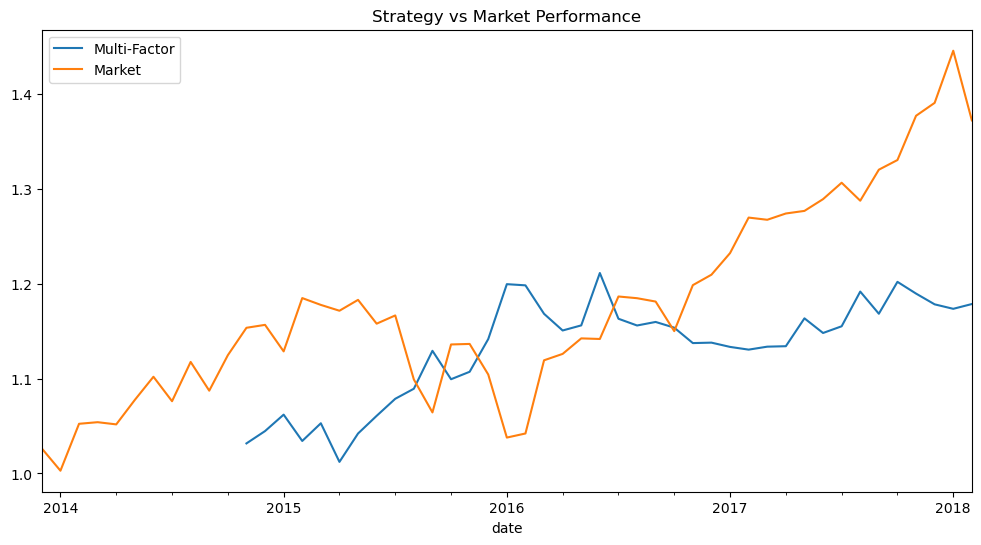

<Figure size 1200x600 with 0 Axes>

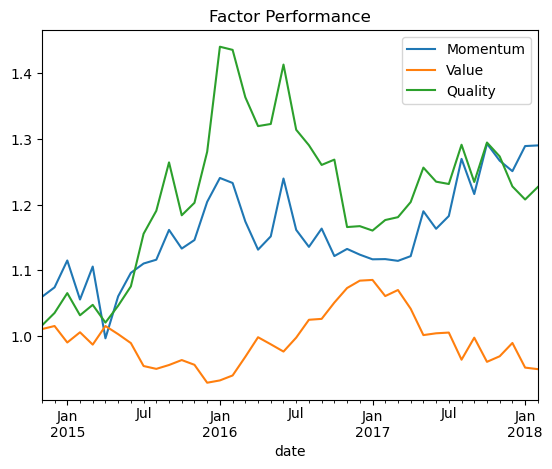

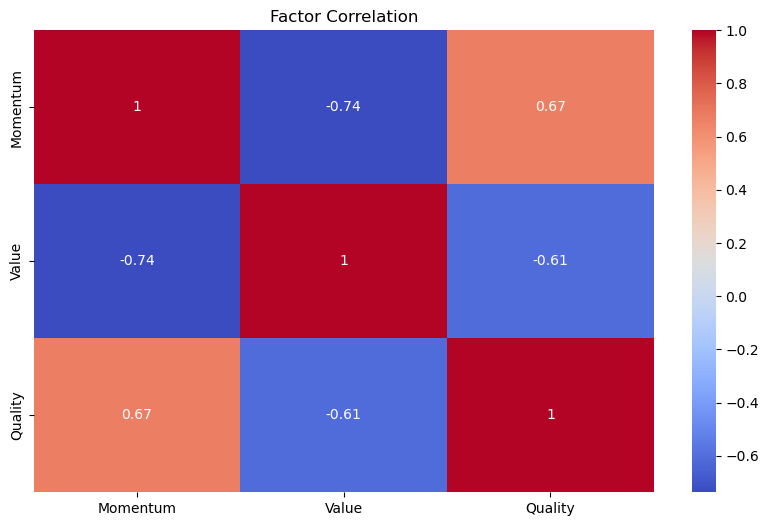

In [27]:
#12. VISUALIZATION
# ============================================

plt.figure(figsize=(12,6))
multi_cum.plot(label="Multi-Factor")
market_cum.plot(label="Market")
plt.title("Strategy vs Market Performance")
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
factor_cum.plot()
plt.title("Factor Performance")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Factor Correlation")
plt.show()

<Figure size 1200x600 with 0 Axes>

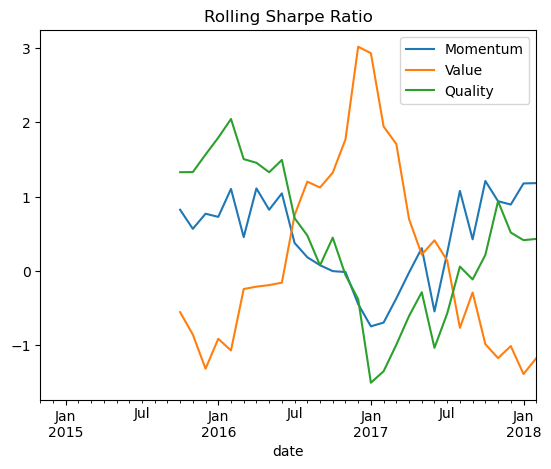

In [29]:
# 13. ROLLING SHARPE
# ============================================

rolling_sharpe = (
    factors.rolling(12)
    .mean() / factors.rolling(12).std()
) * np.sqrt(12)

plt.figure(figsize=(12,6))
rolling_sharpe.plot()
plt.title("Rolling Sharpe Ratio")
plt.show()

In [31]:
# 14. REPORT OUTPUT
# ============================================

print("====================================")
print(" QUANT FACTOR INVESTING REPORT ")
print("====================================\n")

print("Factor Performance:\n")
print(summary, "\n")

print("Multi-Factor Performance:\n")
print(multi_summary, "\n")

print("Correlation Matrix:\n")
print(corr_matrix)

 QUANT FACTOR INVESTING REPORT 

Factor Performance:

          Annual Return  Volatility    Sharpe  Max Drawdown
Momentum       0.086137    0.139095  0.619266     -0.106313
Value         -0.012798    0.074937 -0.170787     -0.125183
Quality        0.071863    0.146703  0.489853     -0.194371 

Multi-Factor Performance:

       Annual Return  Volatility    Sharpe  Max Drawdown
Multi       0.052174    0.075987  0.686624     -0.066666 

Correlation Matrix:

          Momentum     Value   Quality
Momentum  1.000000 -0.737482  0.672650
Value    -0.737482  1.000000 -0.613155
Quality   0.672650 -0.613155  1.000000


In [33]:
# ============================================
# 15. CAPM REGRESSION (ALPHA & BETA)
# ============================================

import statsmodels.api as sm

def capm_analysis(strategy_returns, market_returns):

    aligned = pd.concat([strategy_returns, market_returns], axis=1).dropna()
    aligned.columns = ["Strategy", "Market"]

    X = sm.add_constant(aligned["Market"])
    y = aligned["Strategy"]

    model = sm.OLS(y, X).fit()

    alpha = model.params["const"] * 12
    beta = model.params["Market"]

    return alpha, beta, model.summary()

alpha, beta, capm_summary = capm_analysis(multi_factor, market)

print("\n====================================")
print("CAPM ANALYSIS")
print("====================================")

print(f"Alpha (Annualized): {alpha:.4f}")
print(f"Beta: {beta:.4f}")


CAPM ANALYSIS
Alpha (Annualized): 0.0801
Beta: -0.4293


In [34]:
# ============================================
# 16. INFORMATION RATIO
# ============================================

excess_returns = multi_factor - market

information_ratio = (
    excess_returns.mean() /
    excess_returns.std()
) * np.sqrt(12)

print("\nInformation Ratio:", information_ratio)


Information Ratio: -0.0801344198055849


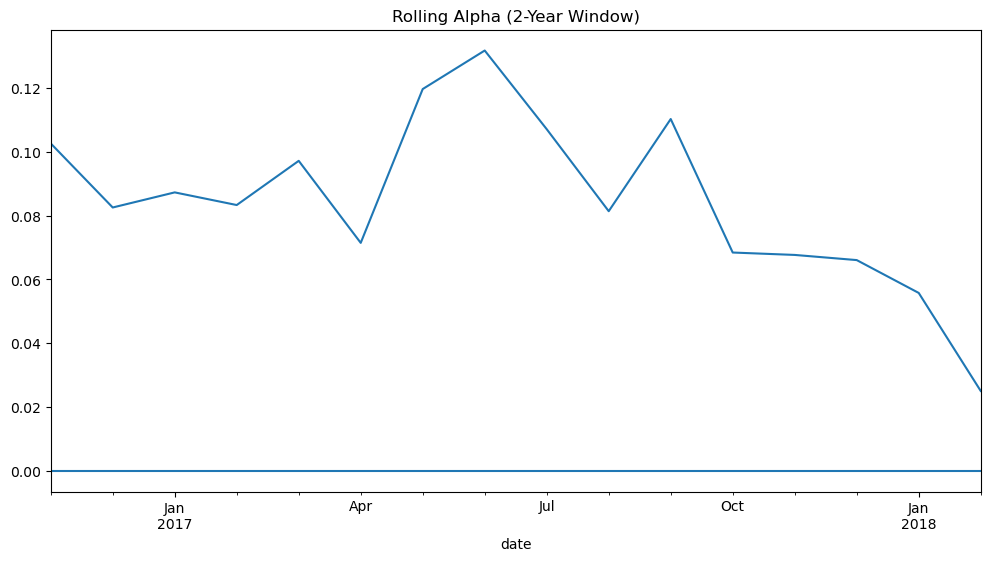

In [37]:
# ============================================
# 17. ROLLING ALPHA
# ============================================

rolling_alpha = []

window = 24

for i in range(window, len(multi_factor)):
    
    strat_slice = multi_factor.iloc[i-window:i]
    market_slice = market.iloc[i-window:i]
    
    aligned = pd.concat([strat_slice, market_slice], axis=1).dropna()
    aligned.columns = ["Strategy", "Market"]
    
    X = sm.add_constant(aligned["Market"])
    y = aligned["Strategy"]
    
    model = sm.OLS(y, X).fit()
    
    rolling_alpha.append(model.params["const"] * 12)

rolling_alpha = pd.Series(
    rolling_alpha,
    index=multi_factor.index[window:]
)

plt.figure(figsize=(12,6))
rolling_alpha.plot()
plt.title("Rolling Alpha (2-Year Window)")
plt.axhline(0)
plt.show()

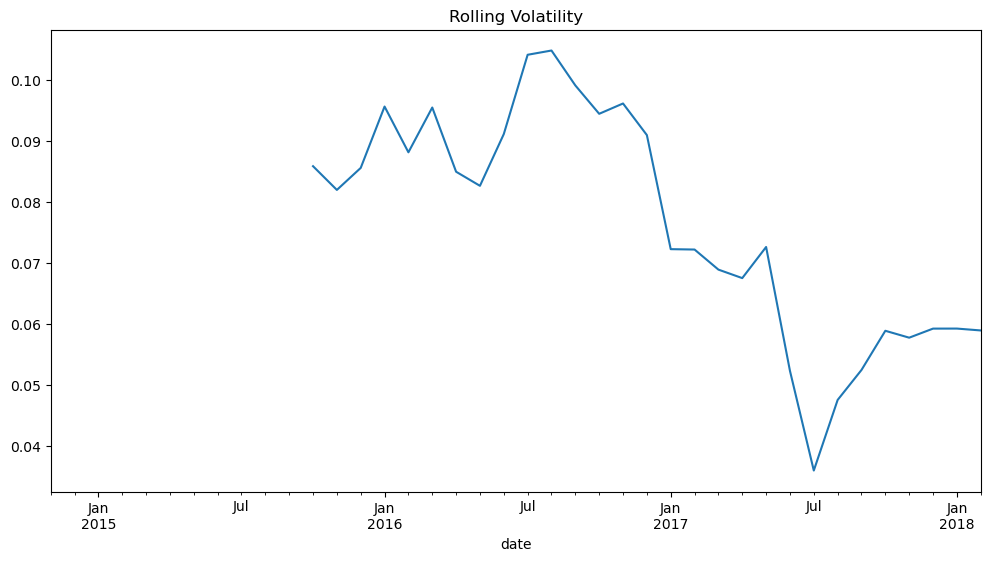

In [39]:
# ============================================
# 18. ROLLING VOLATILITY
# ============================================

rolling_vol = multi_factor.rolling(12).std() * np.sqrt(12)

plt.figure(figsize=(12,6))
rolling_vol.plot()
plt.title("Rolling Volatility")
plt.show()

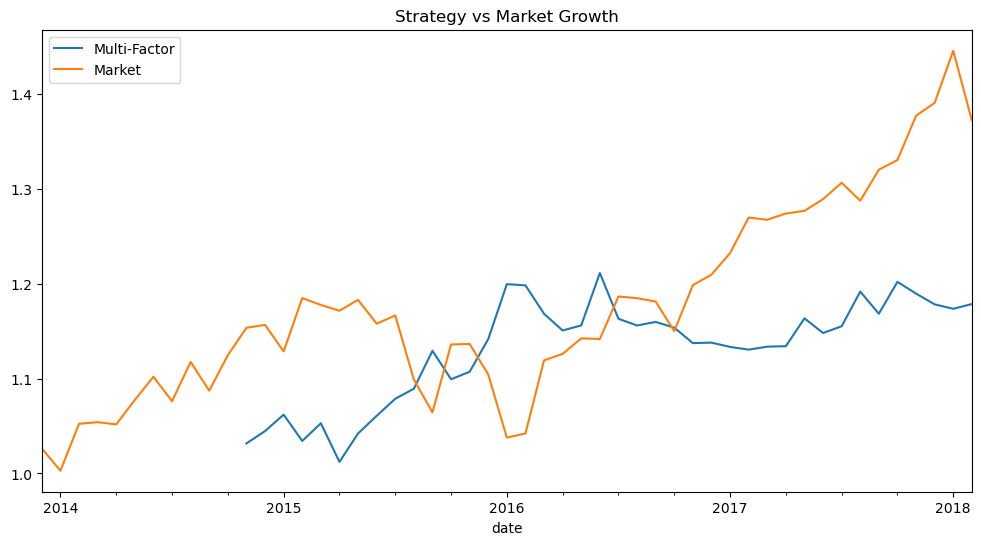

In [41]:
plt.figure(figsize=(12,6))

multi_cum.plot(label="Multi-Factor")
market_cum.plot(label="Market")

plt.title("Strategy vs Market Growth")
plt.legend()
plt.show()

In [43]:
# ============================================
# CURRENT STOCK PICKS FROM STRATEGY
# ============================================

latest_date = momentum.index[-1]

scores = (
    momentum.loc[latest_date] +
    value.loc[latest_date] +
    quality.loc[latest_date]
)

scores = scores.dropna()

top_stocks = scores.sort_values(ascending=False).head(10)
bottom_stocks = scores.sort_values().head(10)

print("\nTop Stocks (Buy Candidates):")
print(top_stocks)

print("\nWorst Stocks (Short / Avoid):")
print(bottom_stocks)


Top Stocks (Buy Candidates):
Name
KORS    0.681914
ABBV    0.508087
DLTR    0.501398
STX     0.498247
GWW     0.477730
KSS     0.423510
MU      0.419873
URI     0.416816
RL      0.405281
ROST    0.391283
Name: 2018-02-28 00:00:00, dtype: float64

Worst Stocks (Short / Avoid):
Name
NWL    -0.604160
PCG    -0.446733
SCG    -0.441248
CELG   -0.431121
UAA    -0.410798
INCY   -0.396320
RRC    -0.381445
AGN    -0.378227
GE     -0.373154
REGN   -0.349204
Name: 2018-02-28 00:00:00, dtype: float64


In [45]:
# ============================================
# BUILD ACTUAL PORTFOLIO FROM STRATEGY
# ============================================

portfolio_size = 10
capital = 10000

latest_date = momentum.index[-1]

# Combine factor scores
scores = (
    momentum.loc[latest_date] +
    value.loc[latest_date] +
    quality.loc[latest_date]
)

scores = scores.dropna()

# Select top stocks
top_stocks = scores.sort_values(ascending=False).head(portfolio_size)

# Get latest prices
latest_prices = monthly_prices.loc[latest_date, top_stocks.index]

allocation_per_stock = capital / portfolio_size

shares = allocation_per_stock / latest_prices

portfolio = pd.DataFrame({
    "Stock": top_stocks.index,
    "Score": top_stocks.values,
    "Price": latest_prices.values,
    "Investment (£)": allocation_per_stock,
    "Shares to Buy": shares.values
})

print("\n====================================")
print(" MODEL PORTFOLIO (SIMULATED)")
print("====================================")
print(portfolio)


 MODEL PORTFOLIO (SIMULATED)
  Stock     Score   Price  Investment (£)  Shares to Buy
0  KORS  0.681914   66.11          1000.0      15.126305
1  ABBV  0.508087  113.62          1000.0       8.801267
2  DLTR  0.501398  106.08          1000.0       9.426848
3   STX  0.498247   49.55          1000.0      20.181635
4   GWW  0.477730  259.89          1000.0       3.847782
5   KSS  0.423510   62.92          1000.0      15.893198
6    MU  0.419873   42.01          1000.0      23.803856
7   URI  0.416816  173.58          1000.0       5.761032
8    RL  0.405281  107.70          1000.0       9.285051
9  ROST  0.391283   77.99          1000.0      12.822157


In [47]:
# ============================================
# RISK-ADJUSTED PORTFOLIO (VOLATILITY WEIGHTED)
# ============================================

portfolio_size = 10
capital = 10000

latest_date = momentum.index[-1]

# Combine factor scores
scores = (
    momentum.loc[latest_date] +
    value.loc[latest_date] +
    quality.loc[latest_date]
)

scores = scores.dropna()

# Select top stocks
top_stocks = scores.sort_values(ascending=False).head(portfolio_size)

# Get prices
latest_prices = monthly_prices.loc[latest_date, top_stocks.index]

# Get volatility
volatility = monthly_returns[top_stocks.index].rolling(12).std().iloc[-1]

# Inverse volatility weights
inv_vol = 1 / volatility
weights = inv_vol / inv_vol.sum()

# Capital allocation
investment = weights * capital

shares = investment / latest_prices

optimized_portfolio = pd.DataFrame({
    "Stock": top_stocks.index,
    "Score": top_stocks.values,
    "Price": latest_prices.values,
    "Weight": weights.values,
    "Investment (£)": investment.values,
    "Shares": shares.values
})

print("\n====================================")
print(" OPTIMIZED QUANT PORTFOLIO")
print("====================================")
print(optimized_portfolio.sort_values("Weight", ascending=False))


 OPTIMIZED QUANT PORTFOLIO
  Stock     Score   Price    Weight  Investment (£)     Shares
1  ABBV  0.508087  113.62  0.135334     1353.335221  11.911065
2  DLTR  0.501398  106.08  0.116298     1162.975477  10.963193
9  ROST  0.391283   77.99  0.109499     1094.990183  14.040136
7   URI  0.416816  173.58  0.109407     1094.068761   6.302966
0  KORS  0.681914   66.11  0.103825     1038.246094  15.704827
8    RL  0.405281  107.70  0.099929      999.285226   9.278414
5   KSS  0.423510   62.92  0.092112      921.119529  14.639535
6    MU  0.419873   42.01  0.082474      824.744067  19.632089
4   GWW  0.477730  259.89  0.082052      820.517889   3.157174
3   STX  0.498247   49.55  0.069072      690.717554  13.939809


In [49]:
# ============================================
# WALK-FORWARD BACKTEST (REALISTIC SIMULATION)
# ============================================

portfolio_size = 10
capital = 10000

walk_returns = []

dates = monthly_returns.index[12:]  # need history for volatility

for date in dates:

    # Factor scores at this date
    scores = (
        momentum.loc[date] +
        value.loc[date] +
        quality.loc[date]
    ).dropna()

    # Select top stocks
    top_stocks = scores.sort_values(ascending=False).head(portfolio_size)

    # Get next month's returns
    next_month = monthly_returns.loc[date]

    # Volatility for risk weighting
    vol = monthly_returns[top_stocks.index].rolling(12).std().loc[date]

    inv_vol = 1 / vol
    weights = inv_vol / inv_vol.sum()

    # Portfolio return
    portfolio_return = (next_month[top_stocks.index] * weights).sum()

    walk_returns.append(portfolio_return)

walk_returns = pd.Series(walk_returns, index=dates)

# ============================================
# WALK-FORWARD PERFORMANCE
# ============================================

wf_cum = (1 + walk_returns).cumprod()

wf_return = walk_returns.mean() * 12
wf_vol = walk_returns.std() * np.sqrt(12)
wf_sharpe = wf_return / wf_vol

print("\n====================================")
print(" WALK-FORWARD BACKTEST RESULTS")
print("====================================")

print(f"Annual Return: {wf_return:.2%}")
print(f"Volatility: {wf_vol:.2%}")
print(f"Sharpe Ratio: {wf_sharpe:.2f}")


 WALK-FORWARD BACKTEST RESULTS
Annual Return: 11.98%
Volatility: 13.16%
Sharpe Ratio: 0.91


In [51]:
# ============================================
# ADD TRANSACTION COSTS
# ============================================

transaction_cost = 0.0015  # 0.15%

walk_returns_tc = []

prev_weights = None

for date in dates:

    scores = (
        momentum.loc[date] +
        value.loc[date] +
        quality.loc[date]
    ).dropna()

    top_stocks = scores.sort_values(ascending=False).head(portfolio_size)

    next_month = monthly_returns.loc[date]

    vol = monthly_returns[top_stocks.index].rolling(12).std().loc[date]
    inv_vol = 1 / vol
    weights = inv_vol / inv_vol.sum()

    portfolio_return = (next_month[top_stocks.index] * weights).sum()

    # Turnover calculation
    if prev_weights is not None:
        turnover = np.abs(weights - prev_weights).sum()
    else:
        turnover = 1

    cost = turnover * transaction_cost

    portfolio_return = portfolio_return - cost

    walk_returns_tc.append(portfolio_return)

    prev_weights = weights

walk_returns_tc = pd.Series(walk_returns_tc, index=dates)

In [53]:
# ============================================
# BENCHMARK COMPARISON
# ============================================

market = monthly_returns.mean(axis=1)

market_return = market.mean() * 12
market_vol = market.std() * np.sqrt(12)
market_sharpe = market_return / market_vol

strategy_return = walk_returns.mean() * 12
strategy_vol = walk_returns.std() * np.sqrt(12)
strategy_sharpe = strategy_return / strategy_vol

comparison = pd.DataFrame({
    "Annual Return": [strategy_return, market_return],
    "Volatility": [strategy_vol, market_vol],
    "Sharpe": [strategy_sharpe, market_sharpe]
}, index=["Strategy", "Market"])

print("\nStrategy vs Market")
print(comparison)


Strategy vs Market
          Annual Return  Volatility    Sharpe
Strategy       0.119823    0.131645  0.910199
Market         0.079576    0.100372  0.792817


In [55]:
# ============================================
# FACTOR CONTRIBUTION
# ============================================

factor_performance = pd.DataFrame({
    "Momentum": mom_port,
    "Value": val_port,
    "Quality": qual_port
})

contribution = factor_performance.mean() * 12

print("\nFactor Contribution (Annual Return)")
print(contribution.sort_values(ascending=False))


Factor Contribution (Annual Return)
Quality     0.083863
Momentum    0.077399
Value       0.010389
dtype: float64
